# Step 3: VQE Optimization with ML Error Mitigation

Plugs trained RF and MLP models into a VQE optimization loop and compares:
- **Ideal VQE**: noiseless simulation (ground truth)
- **Noisy VQE**: FakeLima noise, no correction
- **RF-mitigated VQE**: FakeLima noise + RF correction at each iteration
- **MLP-mitigated VQE**: FakeLima noise + MLP correction at each iteration

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import joblib
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.primitives import StatevectorEstimator
from qiskit import transpile

from qiskit_aer.primitives import Estimator as AerEstimatorV1
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeLimaV2

print('All imports OK')

All imports OK


## 1. Setup: Hamiltonian, Ansatz, Noise, Estimators

Recreates the exact same setup as the data generation notebook.

In [35]:
# ── H2 Hamiltonian at equilibrium (0.735 Angstrom) ────────────────────────────
PAULI_LABELS = ['II', 'IZ', 'ZI', 'ZZ', 'XX']
H2_COEFFS    = [-1.0523732, 0.39793742, -0.39793742, -0.01128010, 0.18093120]
pauli_ops    = [SparsePauliOp(p) for p in PAULI_LABELS]

# Exact ground state energy by diagonalization
def exact_energy(coeffs):
    c0, c1, c2, c3, c4 = coeffs
    H = np.zeros((4, 4))
    H[0,0] = c0 + c1 + c2 + c3
    H[1,1] = c0 - c1 + c2 - c3
    H[2,2] = c0 + c1 - c2 - c3
    H[3,3] = c0 - c1 - c2 + c3
    H[0,3] = H[3,0] = c4
    H[1,2] = H[2,1] = c4
    return np.min(np.linalg.eigvalsh(H))

E_EXACT = exact_energy(H2_COEFFS)
print(f'Exact ground state energy: {E_EXACT:.6f} Ha')

# ── Ansatz (must match data generation) ───────────────────────────────────────
ansatz = TwoLocal(num_qubits=2, rotation_blocks='ry',
                  entanglement_blocks='cx', entanglement='linear', reps=3)
num_params = ansatz.num_parameters
print(f'Ansatz parameters: {num_params}')

# Transpile to basis gates
transpiled_ansatz = transpile(ansatz, basis_gates=['rz', 'sx', 'cx', 'x'],
                              optimization_level=1)
print(f'Transpiled depth: {transpiled_ansatz.depth()}')

# ── Noise model and estimators ────────────────────────────────────────────────
backend = FakeLimaV2()
noise_model = NoiseModel.from_backend(backend)

ideal_estimator = StatevectorEstimator()

noisy_estimator = AerEstimatorV1()
noisy_estimator.set_options(noise_model=noise_model, shots=10000)

print('Estimators ready.')

Exact ground state energy: -1.857275 Ha
Ansatz parameters: 8
Transpiled depth: 19
Estimators ready.


## 2. Load RF Model and Define Correction

Feature vector (13 columns) must exactly match training:

`[noisy_val, x_q0, x_q1, z_q0, z_q1, n_2q, n_sx, T1_q0*m0, T2_q0*m0, ro_q0*m0, T1_q1*m1, T2_q1*m1, ro_q1*m1]`

where `m0`, `m1` are masks derived from the symplectic encoding.

In [36]:
# Load trained RF
rf = joblib.load('rf_mlqem.joblib')
print(f'RF model loaded: {rf.n_estimators} trees, {rf.n_features_in_} features')

# Circuit features (same as training)
N_2Q = 3
N_SX = 8

# Per-qubit noise parameters from FakeLimaV2
props = backend.properties()
QUBIT_NOISE = {}
for q in range(2):
    QUBIT_NOISE[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

# Symplectic encoding
def pauli_to_symplectic(label):
    p = Pauli(label)
    return np.concatenate([p.x.astype(int), p.z.astype(int)])

PAULI_ENCODINGS = {label: pauli_to_symplectic(label) for label in PAULI_LABELS}

def build_correction_features(noisy_val, pauli_label):
    symp = PAULI_ENCODINGS[pauli_label]
    x_q0, x_q1, z_q0, z_q1 = symp
    mask_q0 = max(x_q0, z_q0)
    mask_q1 = max(x_q1, z_q1)
    q0 = QUBIT_NOISE[0]; q1 = QUBIT_NOISE[1]
    return [noisy_val, x_q0, x_q1, z_q0, z_q1, N_2Q, N_SX,
            q0['T1']*mask_q0, q0['T2']*mask_q0, q0['readout_error']*mask_q0,
            q1['T1']*mask_q1, q1['T2']*mask_q1, q1['readout_error']*mask_q1]

test_feat = build_correction_features(0.5, 'ZZ')
assert len(test_feat) == rf.n_features_in_
print(f'Feature construction verified: {len(test_feat)} features')

# ── Train MLP for VQE correction ──
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

# Load training data
ideal_data = np.load('ideal_data.npy')
noisy_data = np.load('noisy_data.npy')
ALL_OBS = [1, 2, 3, 4]

def build_features_batch(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        for i in range(len(noisy_subset)):
            rows_X.append(build_correction_features(noisy_subset[i, obs_idx], label))
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

X_train_mlp, y_train_mlp = build_features_batch(noisy_data[:1800], ideal_data[:1800], ALL_OBS)

n_val = int(0.2 * len(X_train_mlp))
idx_perm = np.random.RandomState(42).permutation(len(X_train_mlp))
val_idx, train_idx = idx_perm[:n_val], idx_perm[n_val:]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_mlp[train_idx])
X_val_sc = scaler.transform(X_train_mlp[val_idx])

Xt = torch.tensor(X_tr_sc, dtype=torch.float32)
yt = torch.tensor(y_train_mlp[train_idx], dtype=torch.float32).unsqueeze(1)
Xv = torch.tensor(X_val_sc, dtype=torch.float32)

torch.manual_seed(2)
mlp_model = MLP(X_train_mlp.shape[1])
opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.HuberLoss()

best_val, best_state, no_imp = float('inf'), None, 0
for epoch in range(1000):
    mlp_model.train(); opt.zero_grad(); crit(mlp_model(Xt), yt).backward(); opt.step()
    mlp_model.eval()
    with torch.no_grad():
        vm = mean_absolute_error(y_train_mlp[val_idx], mlp_model(Xv).numpy().ravel())
    if vm < best_val - 1e-6:
        best_val = vm; best_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}; no_imp = 0
    else: no_imp += 1
    if no_imp >= 25: break

mlp_model.load_state_dict(best_state); mlp_model.eval()
print(f'MLP trained (stopped at epoch {epoch+1})')

RF model loaded: 100 trees, 13 features
Feature construction verified: 13 features
MLP trained (stopped at epoch 668)


## 3. VQE Cost Functions

Four cost functions for the optimizer:
- `ideal_cost`: exact statevector evaluation (no noise)
- `noisy_cost`: noisy evaluation (FakeLima + shot noise)
- `mitigated_cost`: noisy evaluation + RF correction per observable
- `mlp_mitigated_cost`: noisy evaluation + MLP correction per observable

In [37]:
def ideal_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = ideal_estimator.run([(bound, op) for op in pauli_ops])
    result = job.result()
    exp_vals = [result[j].data.evs for j in range(len(PAULI_LABELS))]
    return sum(c * v for c, v in zip(H2_COEFFS, exp_vals))

def noisy_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    return sum(c * v for c, v in zip(H2_COEFFS, result.values))

def mitigated_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    corrected = []
    for j, (label, val) in enumerate(zip(PAULI_LABELS, result.values)):
        if j == 0: corrected.append(1.0)
        else: corrected.append(rf.predict([build_correction_features(val, label)])[0])
    return sum(c * v for c, v in zip(H2_COEFFS, corrected))

def mlp_mitigated_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    corrected = []
    for j, (label, val) in enumerate(zip(PAULI_LABELS, result.values)):
        if j == 0: corrected.append(1.0)
        else:
            feats = np.array([build_correction_features(val, label)], dtype=np.float32)
            feats_sc = scaler.transform(feats)
            mlp_model.eval()
            with torch.no_grad():
                corrected.append(mlp_model(torch.tensor(feats_sc)).item())
    return sum(c * v for c, v in zip(H2_COEFFS, corrected))

theta_test = np.zeros(num_params)
print(f'Quick test at theta=0:')
print(f'  Ideal:         {ideal_cost(theta_test):.6f}')
print(f'  Noisy:         {noisy_cost(theta_test):.6f}')
print(f'  RF-mitigated:  {mitigated_cost(theta_test):.6f}')
print(f'  MLP-mitigated: {mlp_mitigated_cost(theta_test):.6f}')
print(f'  Exact GS:      {E_EXACT:.6f}')

Quick test at theta=0:
  Ideal:         -1.063653
  Noisy:         -1.067566
  RF-mitigated:  -1.062535
  MLP-mitigated: -1.065737
  Exact GS:      -1.857275


## 4. Run VQE Optimization

COBYLA optimizer, 200 iterations, same initial point for all 3 methods.

Expected runtime: ~5–10 minutes (noisy evaluations dominate).

In [38]:
MAXITER = 200
np.random.seed(42)
theta0 = np.random.randn(num_params) * 0.1

def run_vqe(cost_fn, label, theta_init=None, maxiter=MAXITER):
    if theta_init is None: theta_init = theta0
    history = []
    def tracked_cost(theta):
        e = cost_fn(theta); history.append(e)
        if len(history) % 25 == 0: print(f'    [{label}] iter {len(history):>3}: E = {e:.6f}')
        return e
    print(f'  Starting {label} VQE ({maxiter} iterations)...')
    result = minimize(tracked_cost, theta_init.copy(), method='COBYLA',
                      options={'maxiter': maxiter, 'rhobeg': 0.5})
    print(f'  {label} done: E = {result.fun:.6f} ({len(history)} evaluations)')
    return result.fun, result.x, history

print('Running VQE optimizations...\n')
E_ideal, theta_ideal, hist_ideal = run_vqe(ideal_cost, 'Ideal')
print()
E_noisy, theta_noisy, hist_noisy = run_vqe(noisy_cost, 'Noisy')
print()
E_mitig, theta_mitig, hist_mitig = run_vqe(mitigated_cost, 'RF-mitigated')
print()
E_mlp_mit, theta_mlp, hist_mlp = run_vqe(mlp_mitigated_cost, 'MLP-mitigated')

print('\n' + '='*55)
print(f'Exact ground state:  {E_EXACT:.6f} Ha')
print(f'Ideal VQE:           {E_ideal:.6f} Ha  (error: {abs(E_ideal - E_EXACT):.6f})')
print(f'Noisy VQE:           {E_noisy:.6f} Ha  (error: {abs(E_noisy - E_EXACT):.6f})')
print(f'RF-mitigated VQE:    {E_mitig:.6f} Ha  (error: {abs(E_mitig - E_EXACT):.6f})')
print(f'MLP-mitigated VQE:   {E_mlp_mit:.6f} Ha  (error: {abs(E_mlp_mit - E_EXACT):.6f})')

Running VQE optimizations...

  Starting Ideal VQE (200 iterations)...
    [Ideal] iter  25: E = -1.852209
    [Ideal] iter  50: E = -1.857270
    [Ideal] iter  75: E = -1.857275
  Ideal done: E = -1.857275 (95 evaluations)

  Starting Noisy VQE (200 iterations)...
    [Noisy] iter  25: E = -1.816432
    [Noisy] iter  50: E = -1.814003
    [Noisy] iter  75: E = -1.814315
  Noisy done: E = -1.811782 (81 evaluations)

  Starting RF-mitigated VQE (200 iterations)...
    [RF-mitigated] iter  25: E = -1.842703
    [RF-mitigated] iter  50: E = -1.852761
    [RF-mitigated] iter  75: E = -1.853798
  RF-mitigated done: E = -1.858475 (84 evaluations)

  Starting MLP-mitigated VQE (200 iterations)...
    [MLP-mitigated] iter  25: E = -1.796173
    [MLP-mitigated] iter  50: E = -1.848028
    [MLP-mitigated] iter  75: E = -1.846070
    [MLP-mitigated] iter 100: E = -1.852065
  MLP-mitigated done: E = -1.846938 (111 evaluations)

Exact ground state:  -1.857275 Ha
Ideal VQE:           -1.857275 Ha  (

## 5. Convergence Plot

Energy vs VQE iteration for all 3 methods. This is the headline result.

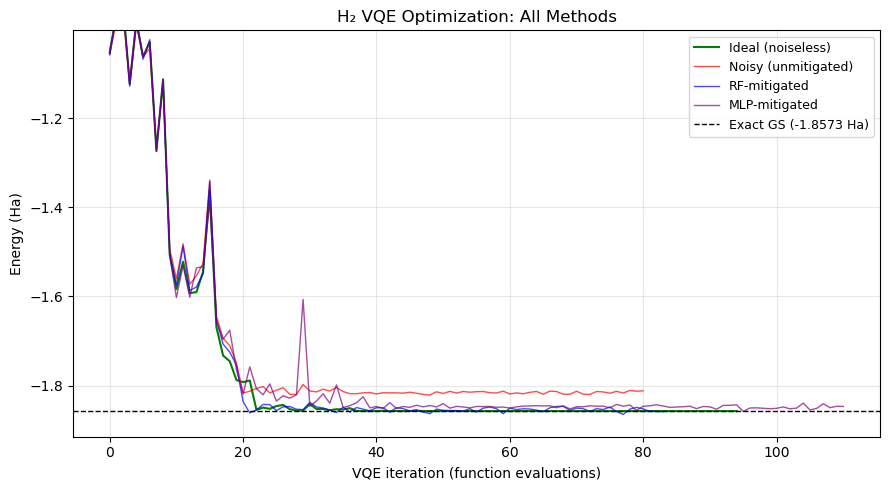

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_ideal, color='green', linewidth=1.5, label='Ideal (noiseless)')
ax.plot(hist_noisy, color='red', alpha=0.7, linewidth=1, label='Noisy (unmitigated)')
ax.plot(hist_mitig, color='blue', alpha=0.7, linewidth=1, label='RF-mitigated')
ax.plot(hist_mlp, color='purple', alpha=0.7, linewidth=1, label='MLP-mitigated')
ax.axhline(E_EXACT, color='black', linestyle='--', linewidth=1, label=f'Exact GS ({E_EXACT:.4f} Ha)')
ax.set_xlabel('VQE iteration (function evaluations)')
ax.set_ylabel('Energy (Ha)')
ax.set_title('H\u2082 VQE Optimization: All Methods')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
y_min = min(min(hist_ideal), min(hist_mitig), min(hist_mlp), E_EXACT) - 0.05
y_max = max(hist_noisy[0], hist_ideal[0]) + 0.05
ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.savefig('h2_vqe_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Energy Error Comparison

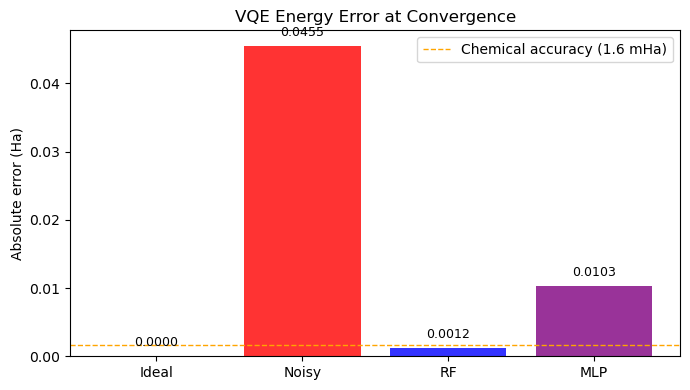

In [40]:
errors = {
    'Ideal': abs(E_ideal - E_EXACT),
    'Noisy': abs(E_noisy - E_EXACT),
    'RF': abs(E_mitig - E_EXACT),
    'MLP': abs(E_mlp_mit - E_EXACT),
}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(errors.keys(), errors.values(), color=['green', 'red', 'blue', 'purple'], alpha=0.8)
ax.axhline(0.0016, color='orange', linestyle='--', linewidth=1, label='Chemical accuracy (1.6 mHa)')
ax.set_ylabel('Absolute error (Ha)'); ax.set_title('VQE Energy Error at Convergence'); ax.legend()
for bar, val in zip(bars, errors.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.savefig('h2_vqe_errors.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Evaluate at Multiple Points (Optional)

For a cleaner comparison, evaluate the energy at the **ideal optimal** $\theta^*$
using noisy and RF-corrected estimators. This isolates the correction quality
from the optimizer's convergence behavior.

Averages over 20 noisy evaluations to reduce shot noise variance.

In [41]:
N_EVAL = 20
print(f'Evaluating {N_EVAL} times at ideal theta* to average out shot noise...\n')
ideal_at_opt = ideal_cost(theta_ideal)
noisy_evals = [noisy_cost(theta_ideal) for _ in range(N_EVAL)]
rf_evals = [mitigated_cost(theta_ideal) for _ in range(N_EVAL)]
mlp_evals = [mlp_mitigated_cost(theta_ideal) for _ in range(N_EVAL)]

print(f'At ideal theta*:')
print(f'  Exact:        {E_EXACT:.6f} Ha')
print(f'  Ideal VQE:    {ideal_at_opt:.6f} Ha')
print(f'  Noisy:        {np.mean(noisy_evals):.6f} ± {np.std(noisy_evals):.4f}  (bias: {np.mean(noisy_evals)-E_EXACT:+.4f})')
print(f'  RF-mitigated: {np.mean(rf_evals):.6f} ± {np.std(rf_evals):.4f}  (bias: {np.mean(rf_evals)-E_EXACT:+.4f})')
print(f'  MLP-mitigated:{np.mean(mlp_evals):.6f} ± {np.std(mlp_evals):.4f}  (bias: {np.mean(mlp_evals)-E_EXACT:+.4f})')
print(f'\nBias reduction (RF):  {abs(np.mean(noisy_evals)-E_EXACT)/abs(np.mean(rf_evals)-E_EXACT):.1f}x')
print(f'Bias reduction (MLP): {abs(np.mean(noisy_evals)-E_EXACT)/abs(np.mean(mlp_evals)-E_EXACT):.1f}x')

Evaluating 20 times at ideal theta* to average out shot noise...

At ideal theta*:
  Exact:        -1.857275 Ha
  Ideal VQE:    -1.857275 Ha
  Noisy:        -1.818145 ± 0.0028  (bias: +0.0391)
  RF-mitigated: -1.857227 ± 0.0041  (bias: +0.0000)
  MLP-mitigated:-1.852829 ± 0.0028  (bias: +0.0044)

Bias reduction (RF):  819.7x
Bias reduction (MLP): 8.8x


## 8. Multiple VQE Runs from Different Initial Points

Run 5 full VQE optimizations from different random initial points to test
whether the RF-mitigated optimizer **consistently** finds the ground state,
not just from one lucky starting point.

In [42]:
N_RUNS = 5
print(f'Running {N_RUNS} VQE optimizations from different initial points...\n')
multi_results = {'ideal': [], 'noisy': [], 'rf': [], 'mlp': []}
multi_histories = {'ideal': [], 'noisy': [], 'rf': [], 'mlp': []}

for run in range(N_RUNS):
    rng = np.random.RandomState(run + 100)
    theta0_run = rng.randn(num_params) * 0.1
    print(f'--- Run {run + 1}/{N_RUNS} ---')
    for cost_fn, label, key in [
        (ideal_cost, f'Ideal-{run+1}', 'ideal'),
        (noisy_cost, f'Noisy-{run+1}', 'noisy'),
        (mitigated_cost, f'RF-{run+1}', 'rf'),
        (mlp_mitigated_cost, f'MLP-{run+1}', 'mlp'),
    ]:
        history = []
        def tracked(theta, hist=history):
            e = cost_fn(theta); hist.append(e); return e
        result = minimize(tracked, theta0_run.copy(), method='COBYLA',
                          options={'maxiter': 200, 'rhobeg': 0.5})
        multi_results[key].append(result.fun)
        multi_histories[key].append(history)
        print(f'  {label}: E = {result.fun:.6f} (error: {abs(result.fun - E_EXACT):.4f})')
    print()

print('=' * 65)
print(f'{"Method":<20} {"Mean E (Ha)":>14} {"Std":>10} {"Mean |error| (mHa)":>20}')
print('-' * 65)
for key, label in [('ideal', 'Ideal'), ('noisy', 'Noisy'), ('rf', 'RF-mitigated'), ('mlp', 'MLP-mitigated')]:
    energies = np.array(multi_results[key])
    errors_ha = np.abs(energies - E_EXACT)
    print(f'{label:<20} {energies.mean():>14.6f} {energies.std():>10.4f} {errors_ha.mean()*1000:>16.2f} mHa')
print(f'\nChemical accuracy: 1.6 mHa')
for key, label in [('rf', 'RF'), ('mlp', 'MLP')]:
    errs = np.abs(np.array(multi_results[key]) - E_EXACT)
    print(f'{label} runs within chem. acc.: {np.sum(errs < 0.0016)}/{N_RUNS}')

Running 5 VQE optimizations from different initial points...

--- Run 1/5 ---
  Ideal-1: E = -1.857275 (error: 0.0000)
  Noisy-1: E = -1.812696 (error: 0.0446)
  RF-1: E = -1.858735 (error: 0.0015)
  MLP-1: E = -1.849314 (error: 0.0080)

--- Run 2/5 ---
  Ideal-2: E = -1.857275 (error: 0.0000)
  Noisy-2: E = -1.813589 (error: 0.0437)
  RF-2: E = -1.854638 (error: 0.0026)
  MLP-2: E = -1.853522 (error: 0.0038)

--- Run 3/5 ---
  Ideal-3: E = -1.857275 (error: 0.0000)
  Noisy-3: E = -1.818337 (error: 0.0389)
  RF-3: E = -1.858329 (error: 0.0011)
  MLP-3: E = -1.850262 (error: 0.0070)

--- Run 4/5 ---
  Ideal-4: E = -1.857275 (error: 0.0000)
  Noisy-4: E = -1.821192 (error: 0.0361)
  RF-4: E = -1.856196 (error: 0.0011)
  MLP-4: E = -1.849140 (error: 0.0081)

--- Run 5/5 ---
  Ideal-5: E = -1.857275 (error: 0.0000)
  Noisy-5: E = -1.817159 (error: 0.0401)
  RF-5: E = -1.855787 (error: 0.0015)
  MLP-5: E = -1.852316 (error: 0.0050)

Method                  Mean E (Ha)        Std   Mean |err

## 9. Multi-Run Convergence Plot

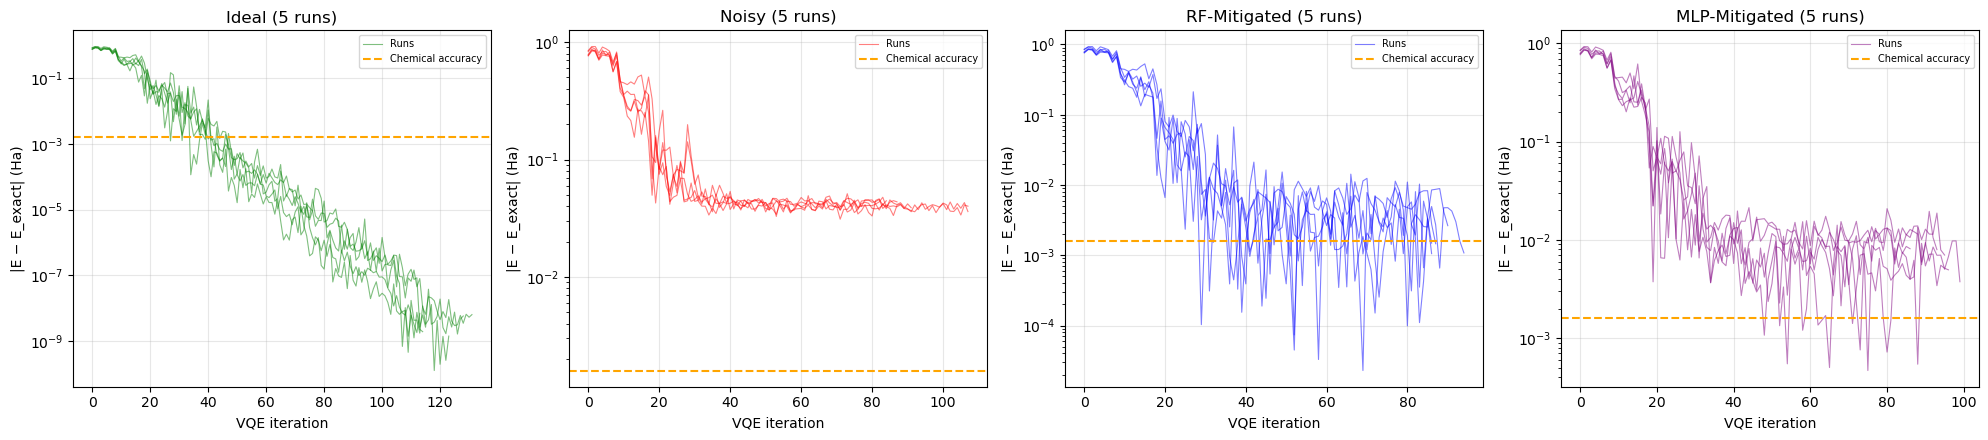

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, key, label, color in [
    (axes[0], 'ideal', 'Ideal', 'green'),
    (axes[1], 'noisy', 'Noisy', 'red'),
    (axes[2], 'rf', 'RF-Mitigated', 'blue'),
    (axes[3], 'mlp', 'MLP-Mitigated', 'purple'),
]:
    for i, hist in enumerate(multi_histories[key]):
        errors = np.abs(np.array(hist) - E_EXACT)
        ax.plot(errors, color=color, alpha=0.5, linewidth=0.8, label='Runs' if i == 0 else None)
    ax.axhline(0.0016, color='orange', linestyle='--', linewidth=1.5, label='Chemical accuracy')
    ax.set_yscale('log'); ax.set_xlabel('VQE iteration'); ax.set_ylabel('|E − E_exact| (Ha)')
    ax.set_title(f'{label} ({N_RUNS} runs)'); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('h2_vqe_multi_run.png', dpi=150, bbox_inches='tight')
plt.show()